In [1]:
import pandas as pd
from sklearn.metrics import classification_report

# Load ONLY the held-out test set (never seen during training)
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\test_set_with_predictions.csv")
# Rebuild city_name from one-hot encoded columns
city_cols = ['city_Faisalabad','city_Islamabad','city_Lahore','city_Multan']
df['city_name'] = df[city_cols].idxmax(axis=1).str.replace('city_', '', regex=False)
def classify_smog_risk_v2(visibility_km):
    if visibility_km < 0.5:
        return "CRITICAL"
    elif visibility_km < 2.0:
        return "HIGH"
    elif visibility_km < 5.0:
        return "MODERATE"
    elif visibility_km < 10.0:
        return "LOW"
    else:
        return "SAFE"

df['actual_risk_v2'] = df['visibility'].apply(classify_smog_risk_v2)
df['predicted_risk_v2'] = df['predicted_visibility'].apply(classify_smog_risk_v2)

risk_order = ['CRITICAL','HIGH','MODERATE','LOW','SAFE']
acc_v2 = (df['actual_risk_v2'] == df['predicted_risk_v2']).sum() / len(df) * 100
print(f"V2 Accuracy (test set only): {acc_v2:.2f}%")

print("\n=== V2 Classification Report (test set only) ===")
print(classification_report(df['actual_risk_v2'], df['predicted_risk_v2'], labels=risk_order))

V2 Accuracy (test set only): 77.10%

=== V2 Classification Report (test set only) ===
              precision    recall  f1-score   support

    CRITICAL       0.61      0.60      0.60       205
        HIGH       0.65      0.52      0.58       826
    MODERATE       0.85      0.77      0.81      3241
         LOW       0.38      0.59      0.46       739
        SAFE       0.90      0.93      0.91      2435

    accuracy                           0.77      7446
   macro avg       0.68      0.68      0.67      7446
weighted avg       0.79      0.77      0.78      7446



In [8]:
import json

# Build a simple summary: latest risk per city, for the frontend
latest = df.sort_values('datetime').groupby('city_name').tail(1)

frontend_data = []
for _, row in latest.iterrows():
    frontend_data.append({
        "city": row['city_name'],
        "datetime": str(row['datetime']),
        "visibility_km": round(float(row['predicted_visibility']), 2),
        "risk_level": row['predicted_risk_v2'],
        "recommendation": row['predicted_recommendation']
    })

output_json_path = r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\latest_risk.json"
with open(output_json_path, 'w') as f:
    json.dump(frontend_data, f, indent=2)

print("Saved latest_risk.json for frontend!")
print(json.dumps(frontend_data, indent=2))

Saved latest_risk.json for frontend!
[
  {
    "city": "Faisalabad",
    "datetime": "2025-02-28 23:00:00",
    "visibility_km": 17.61,
    "risk_level": "SAFE",
    "recommendation": "Normal Operations"
  },
  {
    "city": "Lahore",
    "datetime": "2025-02-28 23:00:00",
    "visibility_km": 3.71,
    "risk_level": "MODERATE",
    "recommendation": "Speed Limit 60 km/h \u2014 Caution Required"
  },
  {
    "city": "Islamabad",
    "datetime": "2025-02-28 23:00:00",
    "visibility_km": 15.62,
    "risk_level": "SAFE",
    "recommendation": "Normal Operations"
  },
  {
    "city": "Multan",
    "datetime": "2025-02-28 23:00:00",
    "visibility_km": 3.77,
    "risk_level": "MODERATE",
    "recommendation": "Speed Limit 60 km/h \u2014 Caution Required"
  }
]


In [2]:
# Add recommendation column
def get_recommendation(visibility_km):
    if visibility_km < 0.5:
        return "Motorway Closure Required"
    elif visibility_km < 2.0:
        return "Speed Limit 40 km/h — Fog Lights Required"
    elif visibility_km < 5.0:
        return "Speed Limit 60 km/h — Caution Required"
    elif visibility_km < 10.0:
        return "Speed Limit 80 km/h — Drive Carefully"
    else:
        return "Normal Operations"

df['actual_recommendation'] = df['visibility'].apply(get_recommendation)
df['predicted_recommendation'] = df['predicted_visibility'].apply(get_recommendation)

# Save final dataset with risk labels
output_path = r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\master_dataset_with_risk.csv"
df.to_csv(output_path, index=False)

print("Dataset with risk labels saved!")
print(f"Final shape: {df.shape}")
print(f"\nSample predictions:")
print(df[['datetime', 'city_name', 'visibility', 
          'predicted_visibility', 'actual_risk_v2', 
          'predicted_risk_v2', 'predicted_recommendation']].head(8))

Dataset with risk labels saved!
Final shape: (7446, 31)

Sample predictions:
              datetime   city_name  visibility  predicted_visibility  \
0  2024-11-29 15:00:00      Lahore         3.1              3.766506   
1  2024-11-29 15:00:00      Multan         2.0              2.194005   
2  2024-11-29 15:00:00   Islamabad        24.1             23.423048   
3  2024-11-29 16:00:00   Islamabad        24.1             19.502302   
4  2024-11-29 16:00:00      Lahore         4.0              3.548242   
5  2024-11-29 16:00:00      Multan         2.0              2.369304   
6  2024-11-29 16:00:00  Faisalabad        24.1             23.701488   
7  2024-11-29 17:00:00      Lahore         2.2              4.158211   

  actual_risk_v2 predicted_risk_v2                predicted_recommendation  
0       MODERATE          MODERATE  Speed Limit 60 km/h — Caution Required  
1       MODERATE          MODERATE  Speed Limit 60 km/h — Caution Required  
2           SAFE              SAFE         

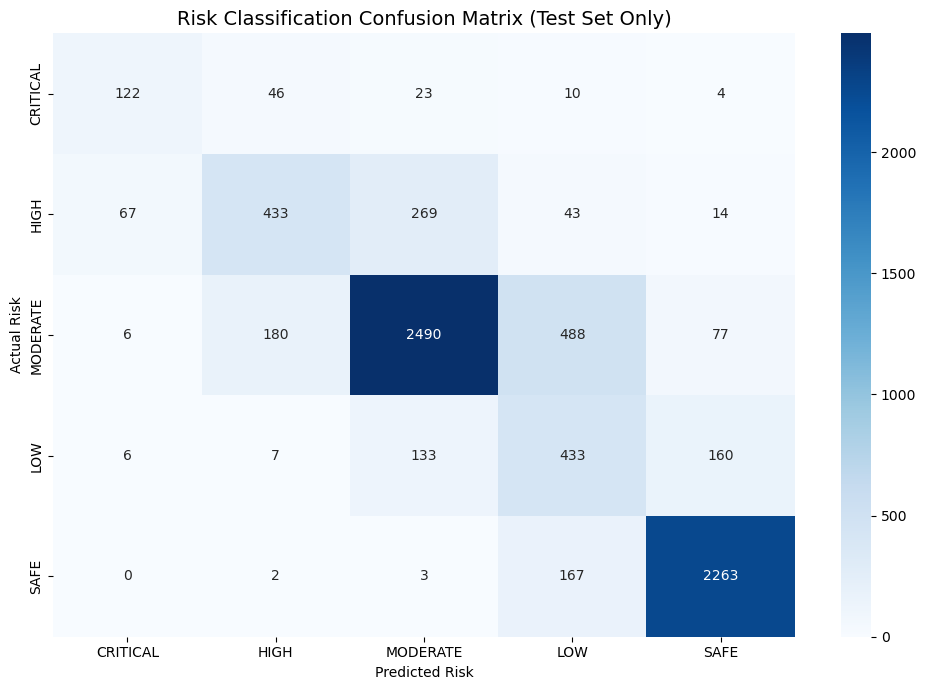

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(df['actual_risk_v2'], df['predicted_risk_v2'], labels=risk_order)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=risk_order, yticklabels=risk_order)
plt.title('Risk Classification Confusion Matrix (Test Set Only)', fontsize=14)
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.tight_layout()
plt.savefig(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\confusion_matrix_v2_testonly.png", dpi=150)
plt.show()